In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_excel("flood dataset.xlsx")

In [3]:
df.head(10)

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0
5,30,70,38,2708.0,34.1,230.0,1943.1,500.8,138.300000,254.1,0
6,29,74,40,3671.1,23.7,328.0,2737.8,581.7,256.966667,669.5,1
7,30,78,36,2648.3,28.8,283.7,2023.6,312.2,197.533333,450.0,0
8,30,71,40,3050.2,65.9,628.3,1940.4,415.5,234.900000,231.5,0
9,30,70,34,2848.6,28.4,296.7,1886.5,637.0,226.666667,531.2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


In [5]:
df.describe()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


In [6]:
df['flood'].unique()

array([0, 1])

In [7]:
df.shape

(115, 11)

In [8]:
df.columns

Index(['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(0)

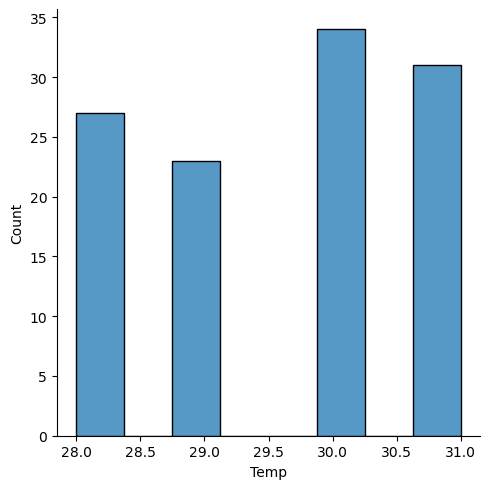

In [10]:
print(sns.displot(df['Temp']))

In [11]:
df.corr()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
Temp,1.000000,-0.012727,-0.046568,-0.063014,-0.080076,0.099519,-0.081965,-0.063034,-0.019751,-0.088331,-0.080946
Humidity,-0.012727,1.000000,0.085824,-0.054767,-0.185965,-0.101232,-0.029583,0.059739,0.017656,0.029981,0.020250
Cloud Cover,-0.046568,0.085824,1.000000,0.051166,0.004376,0.096645,0.010833,0.020966,-0.089843,-0.106455,0.089801
ANNUAL,-0.063014,-0.054767,0.051166,1.000000,0.033639,0.387790,0.861190,0.232069,0.474644,0.220009,0.626874
Jan-Feb,-0.080076,-0.185965,0.004376,0.033639,1.000000,0.066479,0.001178,-0.143670,0.164691,0.201266,-0.084446
Mar-May,0.099519,-0.101232,0.096645,0.387790,0.066479,1.000000,-0.029007,0.171805,0.019183,-0.475750,-0.017598
Jun-Sep,-0.081965,-0.029583,0.010833,0.861190,0.001178,-0.029007,1.000000,-0.141467,0.511113,0.431997,0.705202
Oct-Dec,-0.063034,0.059739,0.020966,0.232069,-0.143670,0.171805,-0.141467,1.000000,-0.028055,-0.050862,-0.024852
avgjune,-0.019751,0.017656,-0.089843,0.474644,0.164691,0.019183,0.511113,-0.028055,1.000000,0.780445,0.379778
sub,-0.088331,0.029981,-0.106455,0.220009,0.201266,-0.475750,0.431997,-0.050862,0.780445,1.000000,0.349828


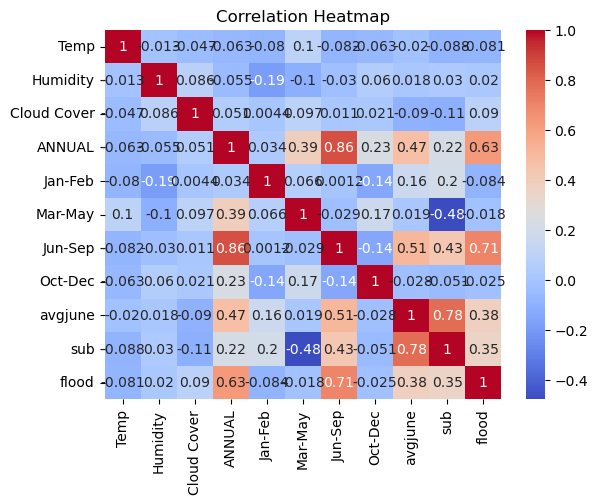

In [12]:
sns.heatmap(df.corr(),annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [13]:
df.drop(['Cloud Cover','Jan-Feb','Mar-May','Oct-Dec'], axis = 1,inplace = True)

In [14]:
df.head()

,Temp,Humidity,ANNUAL,Jun-Sep,avgjune,sub,flood
0,29,70,3248.6,2122.8,274.866667,649.9,0
1,28,75,3326.6,2403.4,130.300000,256.4,1
2,28,75,3271.2,2343.0,186.200000,308.9,0
3,29,71,3129.7,2398.2,366.066667,862.5,0
4,31,74,2741.6,1881.5,283.400000,586.9,0


In [15]:
selected_features = ['Temp','Humidity','ANNUAL','Jun-Sep','avgjune','sub']

Box plot for  Temp


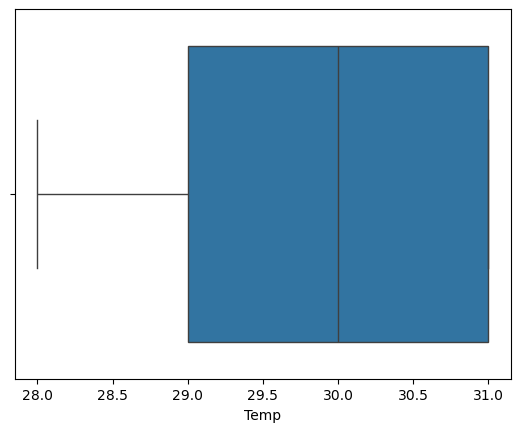

Box plot for  Humidity


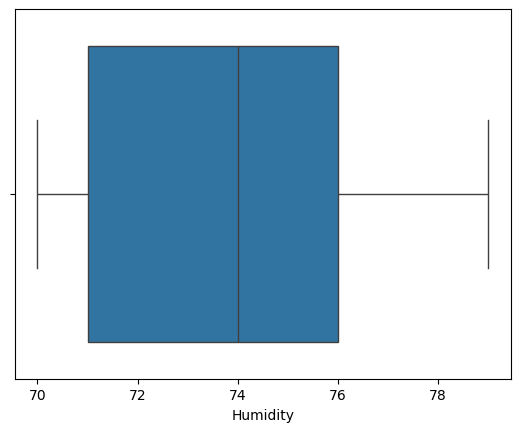

Box plot for  ANNUAL


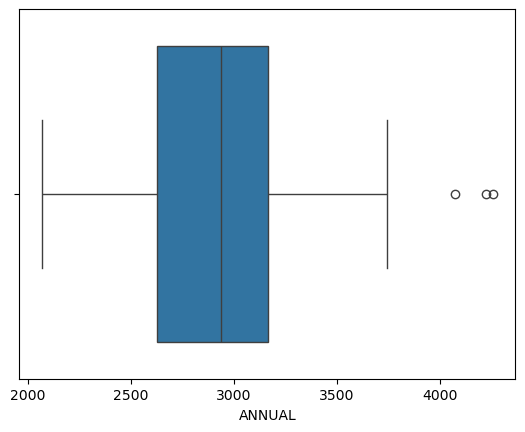

Box plot for  Jun-Sep


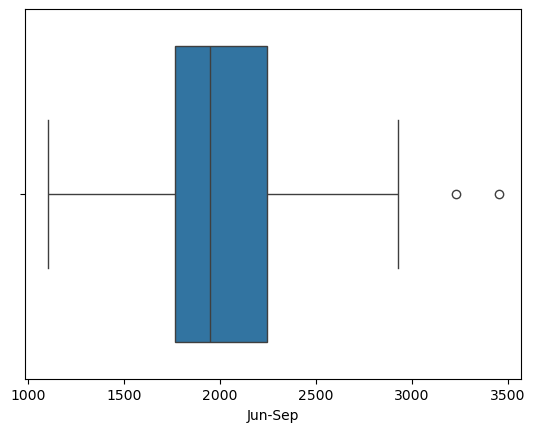

Box plot for  avgjune


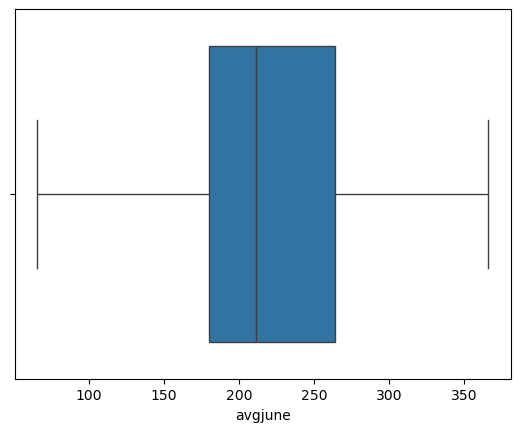

Box plot for  sub


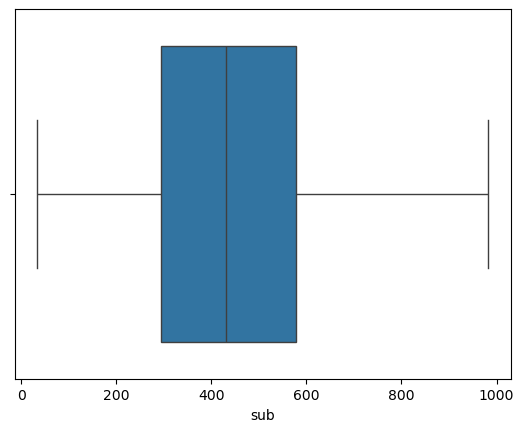

In [16]:
for i in selected_features:
    sns.boxplot(x=df[i],orient= "h")
    print("Box plot for ",i)
    plt.show()

In [17]:
col = ['ANNUAL','Jun-Sep']
for i in col:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[i] = np.where(df[i] < lower_bound, lower_bound, np.where(df[i] > upper_bound, upper_bound, df[i]))

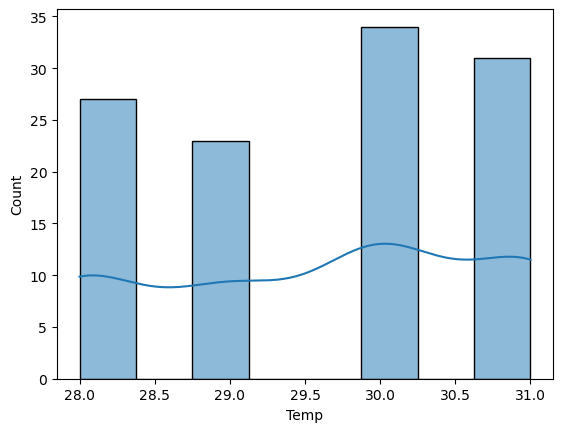

In [18]:
sns.histplot(df['Temp'], kde=True)
plt.show()

In [19]:
df.head()

,Temp,Humidity,ANNUAL,Jun-Sep,avgjune,sub,flood
0,29,70,3248.6,2122.8,274.866667,649.9,0
1,28,75,3326.6,2403.4,130.300000,256.4,1
2,28,75,3271.2,2343.0,186.200000,308.9,0
3,29,71,3129.7,2398.2,366.066667,862.5,0
4,31,74,2741.6,1881.5,283.400000,586.9,0


In [20]:
df['flood'].unique()

array([0, 1])

In [21]:
df.columns

Index(['Temp', 'Humidity', 'ANNUAL', 'Jun-Sep', 'avgjune', 'sub', 'flood'], dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Temp      115 non-null    int64  
 1   Humidity  115 non-null    int64  
 2   ANNUAL    115 non-null    float64
 3   Jun-Sep   115 non-null    float64
 4   avgjune   115 non-null    float64
 5   sub       115 non-null    float64
 6   flood     115 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 6.4 KB


In [23]:
df['flood'].value_counts()

flood
0    99
1    16
Name: count, dtype: int64

In [24]:
x = df.drop('flood', axis = 1)
y = df['flood']

In [25]:
print(x.columns.tolist())

['Temp', 'Humidity', 'ANNUAL', 'Jun-Sep', 'avgjune', 'sub']


In [26]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size = 0.1, random_state =64)

In [27]:
y_test.value_counts()


flood
0    8
1    4
Name: count, dtype: int64

In [28]:
#Decision Tree Classification
def decisionTree(x_train,x_test,y_train,y_test, random_state = 64):
    tree_model = DecisionTreeClassifier(random_state= 64)
    tree_model.fit(x_train,y_train)

    
    tree_pred = tree_model.predict(x_test)
    
    
    accuracy = accuracy_score(y_test, tree_pred)
    c_report = classification_report(y_test, tree_pred)
    con_mat = confusion_matrix(y_test, tree_pred)

    
    print("Accuracy Score:", accuracy)
    print("Classification:",c_report)
    print("Confusion Matrix:", con_mat)

    return tree_model, tree_pred
treeModel, treePred = decisionTree(x_train,x_test,y_train,y_test)

Accuracy Score: 1.0
Classification:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         4

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12

Confusion Matrix: [[8 0]
 [0 4]]


In [29]:
#Normailizing X_train and X_test
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [30]:
#Random Forest Classification
def randomForest(x_train_scaled, x_test_scaled,y_train,y_test, n_estimators = 5, random_state = 64):
    forest_model = RandomForestClassifier(n_estimators = n_estimators, random_state = random_state)
    forest_model.fit(x_train_scaled,y_train)

    rf_pred = forest_model.predict(x_test_scaled)

    rf_accuracy = accuracy_score(y_test,rf_pred)
    rf_cp = classification_report(y_test,rf_pred)
    rf_cm = confusion_matrix(y_test,rf_pred)

    print("Accuracy Score:", rf_accuracy)
    print("Classification:",rf_cp)
    print("Confusion Matrix:", rf_cm)

    return forest_model, rf_pred

forest_model, rf_pred = randomForest(x_train_scaled, x_test_scaled,y_train,y_test)

Accuracy Score: 1.0
Classification:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         4

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12

Confusion Matrix: [[8 0]
 [0 4]]


In [31]:
#KNeighbors Classification
def KNN(x_train_scaled, x_test_scaled, y_train, y_test):
    knn_model = KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(x_train_scaled,y_train)

    knn_pred = knn_model.predict(x_test_scaled)

    knn_accuracy = accuracy_score(y_test, knn_pred)
    knn_cp = classification_report(y_test, knn_pred)
    knn_cm = confusion_matrix(y_test, knn_pred)

    print("Accuracy Score:", knn_accuracy)
    print("Classification:",knn_cp)
    print("Confusion Matrix:", knn_cm)

    return knn_model, knn_pred

knn_model, knn_pred = KNN(x_train_scaled, x_test_scaled, y_train, y_test)

Accuracy Score: 0.9166666666666666
Classification:               precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       1.00      0.75      0.86         4

    accuracy                           0.92        12
   macro avg       0.94      0.88      0.90        12
weighted avg       0.93      0.92      0.91        12

Confusion Matrix: [[8 0]
 [1 3]]


In [32]:
#Gradient Boosting Classification
def xgboost(x_train_scaled,x_test_scaled, y_train, y_test):
    xgb_model = GradientBoostingClassifier()
    xgb_model.fit(x_train_scaled,y_train)

    xgb_pred = xgb_model.predict(x_test_scaled)

    xgb_accuracy = accuracy_score(y_test, xgb_pred)
    xgb_cp = classification_report(y_test, xgb_pred)
    xgb_cm = confusion_matrix(y_test, xgb_pred)


    print("Accuracy Score:", xgb_accuracy)
    print("Classification:", xgb_cp)
    print("Confusion Matrix:", xgb_cm)


    return xgb_model, xgb_pred


xgb_model, xgb_pred = xgboost(x_train_scaled,x_test_scaled, y_train, y_test)

Accuracy Score: 1.0
Classification:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         4

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12

Confusion Matrix: [[8 0]
 [0 4]]


In [33]:
import joblib

In [34]:
joblib.dump(xgb_model, "flood_prediction")
model_xgb = joblib.load("flood_prediction")
joblib.dump(scaler, "flood_prediction_scaler")
scaler_jbl = joblib.load("flood_prediction_scaler")

In [35]:
model_xgb.predict(x_test_scaled)

array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0])

In [41]:
import sys
!{sys.executable} -m pip install pipreqs


Defaulting to user installation because normal site-packages is not writeable


In [46]:
!python -m pipreqs.pipreqs "C:/Users/surendra/Flood Prediction.AI" --force


INFO: Successfully saved requirements file in C:/Users/surendra/Flood Prediction.AI\requirements.txt
